# 3D Diffusion: Slice-Based Visualization

This notebook reloads a trained 3D diffusion checkpoint, samples a volume from the fake-3D inflated dataset, and visualizes the output as depth-wise slices.

The current 3D pipeline inflates 2D fields into a depth axis using `inflate_dim`, so the slice views below let you inspect how the generated output changes across those layers.

In [1]:
import os
import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from diffusionsr.datasets.dataset import SimulationXZDataset
from diffusionsr.runners.train_diffusion_3d import DiffusionModel3D

In [2]:
DIFFUSIONSR_ROOT = "/home/shohom-tfc/src/LPBFDiffusionSR/diffusionsr"
RUN_DIR = "/home/shohom-tfc/src/LPBFDiffusionSR/diffusionsr/runs/direct/diffusionimplicitupscaled/2026_04_27_17_22_41/standardize/n_steps_1"
CONFIG_PATH = os.path.join(RUN_DIR, "configuration.yml")
CKPT_PATH = os.path.join(RUN_DIR, "ckpt.pth")

device = "cuda" if torch.cuda.is_available() else "cpu"

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

print("Checkpoint exists:", os.path.exists(CKPT_PATH))
print("Device:", device)
config

Checkpoint exists: True
Device: cuda


{'root_folder': './data/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame',
 'downscale_method': 'direct',
 'n_steps': '1',
 'encoding': False,
 'residual_flag': False,
 'conditioning': 'implicit',
 'normalize_method': 'standardize',
 'schedule': 'linear',
 'fields': 'temperature',
 'timesteps': 1000,
 'batch_size': 20,
 'epochs': 300,
 'learning_rate': '5e-5',
 'use_pretrained': False,
 'inflate_dim': 4,
 'inflate_method': 'repeat',
 'voxel_save_interval': 50,
 'voxel_sample_batch_idx': 100,
 'voxel_threshold': 1800.0,
 'voxel_channel': 0,
 'voxel_sampler': 'DDIM',
 'voxel_skip': 10}

In [11]:
def config_to_field_names(config_dict):
    fields = config_dict.get("fields")
    if fields == "temperature":
        return ["temperature"]
    if fields == "all":
        return None
    if fields == "all_but_pressure":
        return ["vx", "temperature", "vy", "vz", "liqlabel"]
    if fields == "temperature_liqlabel":
        return ["temperature", "liqlabel"]
    raise ValueError(f"Unsupported fields setting: {fields}")


def resolve_root_folder(config_dict):
    root_folder = config_dict["root_folder"]
    if os.path.isabs(root_folder):
        return root_folder
    return os.path.abspath(os.path.join(DIFFUSIONSR_ROOT, root_folder))


def build_dataset(split):
    return SimulationXZDataset(
        downscale_method=config["downscale_method"],
        root_folder=resolve_root_folder(config),
        split=split,
        normalize=config["normalize_method"],
        n_steps=int(config["n_steps"]),
        field_names=config_to_field_names(config),
        out_steps=config.get("out_steps"),
        inflate_dim=config.get("inflate_dim"),
        inflate_method=config.get("inflate_method", "repeat"),
        return_info=True,
    )


def _select_stats(dataset, input_type):
    if input_type == "hr":
        mean = dataset.mean_hr
        std = dataset.std_hr
    elif input_type == "lr":
        mean = dataset.mean_lr
        std = dataset.std_lr
    elif input_type == "upscaled_lr":
        mean = dataset.mean_upscaled_lr
        std = dataset.std_upscaled_lr
    elif input_type == "residual":
        mean = dataset.mean_resid
        std = dataset.std_resid
    else:
        raise ValueError(f"Unsupported input_type: {input_type}")
    return np.asarray(mean), np.asarray(std)


def unscale_volume(dataset, volume, input_type):
    channels, depth, height, width = volume.shape
    flat = volume.reshape(channels * depth, height, width)

    mean, std = _select_stats(dataset, input_type)

    # Older stats folders are 2D-only, so broadcast the single-field stats
    # across the inflated depth slices used for fake-3D visualization.
    if mean.ndim == 2:
        mean = np.broadcast_to(mean, (channels * depth, height, width))
        std = np.broadcast_to(std, (channels * depth, height, width))
        return (flat * std + mean).reshape(channels, depth, height, width)

    if mean.ndim == 3:
        unscaled = np.asarray(dataset.unscale_data(flat, input_type=input_type))
        return unscaled.reshape(channels, depth, height, width)

    raise ValueError(f"Unexpected stats rank for {input_type}: {mean.ndim}")


def plot_volume_slices(volume, title, cmap="jet", vmin=None, vmax=None):
    channels, depth, _, _ = volume.shape
    fig, axs = plt.subplots(channels, depth, figsize=(3.2 * depth, 3.2 * channels), dpi=150, squeeze=False)
    for channel_idx in range(channels):
        for depth_idx in range(depth):
            ax = axs[channel_idx][depth_idx]
            image = volume[channel_idx, depth_idx]
            im = ax.imshow(image.T, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_title(f"c={channel_idx}, z={depth_idx}")
            ax.set_xticks([])
            ax.set_yticks([])
    fig.suptitle(title)
    fig.tight_layout()
    fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.8)
    plt.show()

In [12]:
train_dataset = build_dataset("train")
dev_dataset = build_dataset("dev")
test_dataset = build_dataset("test")
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=True)

diff_model = DiffusionModel3D(
    results_folder=RUN_DIR,
    lr_encoder_folder=config.get("encoder_results_dir", "no_encoder_used"),
    train_dataset=train_dataset,
    dev_dataset=dev_dataset,
    test_dataset=test_dataset,
    timesteps=int(config["timesteps"]),
    conditioning=config["conditioning"],
    encoding=bool(config["encoding"]),
    schedule=config["schedule"],
    device=device,
    enc_output=config.get("enc_output", False),
    out_steps=config.get("out_steps"),
    transform_rescale=config.get("transform_rescale", False),
)
diff_model.load_saved_model()
diff_model.model.eval()
print("Loaded checkpoint from:", CKPT_PATH)

Using normalize method: ... standardize
Using specific fields, ['temperature']
Processing dataset with 1 fields
Downscale factor:  2
Using normalize method: ... standardize
Using specific fields, ['temperature']
Processing dataset with 1 fields
Downscale factor:  2
Using normalize method: ... standardize
Using specific fields, ['temperature']
Processing dataset with 1 fields
Downscale factor:  2
not loading encoder, ..., encoding = False 
TIMESTEPS == 1000, Schedule = linear
Loading model from /home/shohom-tfc/src/LPBFDiffusionSR/diffusionsr/runs/direct/diffusionimplicitupscaled/2026_04_27_17_22_41/standardize/n_steps_1
model found, loading
Loaded checkpoint from: /home/shohom-tfc/src/LPBFDiffusionSR/diffusionsr/runs/direct/diffusionimplicitupscaled/2026_04_27_17_22_41/standardize/n_steps_1/ckpt.pth


In [13]:
sample_batch_idx = 480
sampler = "DDPM"
skip = 1

for batch_idx, (residual, hr, true_lr, upscaled_lr, info) in enumerate(test_dataloader):
    if batch_idx != sample_batch_idx:
        continue

    batch_3d = diff_model.reshape_to_volume(hr.to(device).float())
    if diff_model.encoding:
        raise NotImplementedError("This notebook currently assumes encoding=False for the 3D run.")
    x_e = diff_model.reshape_to_volume(upscaled_lr.to(device).float())

    all_images = diff_model.batch_sample(
        dataset=test_dataset,
        batch=batch_3d,
        x_e=x_e,
        sampler=sampler,
        skip=skip,
    )

    pred_volume = all_images[-1, 0].detach().cpu().numpy()
    target_volume = batch_3d[0].detach().cpu().numpy()
    input_volume = x_e[0].detach().cpu().numpy()
    metadata = info[0].numpy()
    print("Sample metadata [power, velocity, time]:", metadata)
    break
else:
    raise ValueError(f"Batch index {sample_batch_idx} not found")

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Sample metadata [power, velocity, time]: [1.3e+02 2.0e+02 1.0e-02]


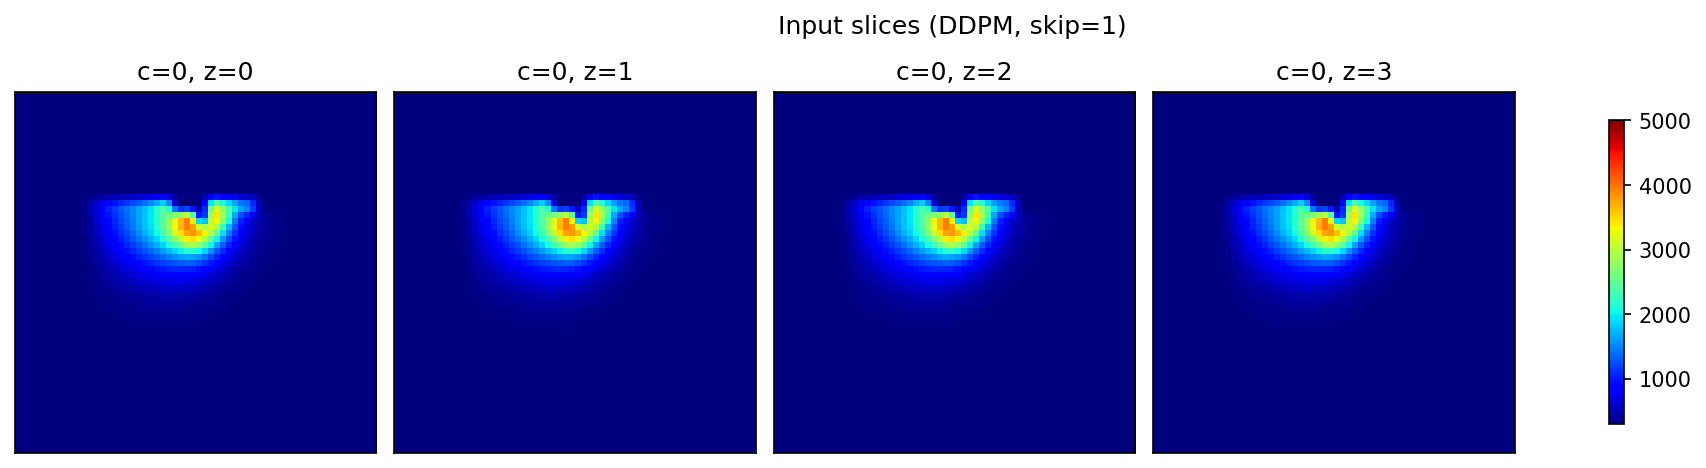

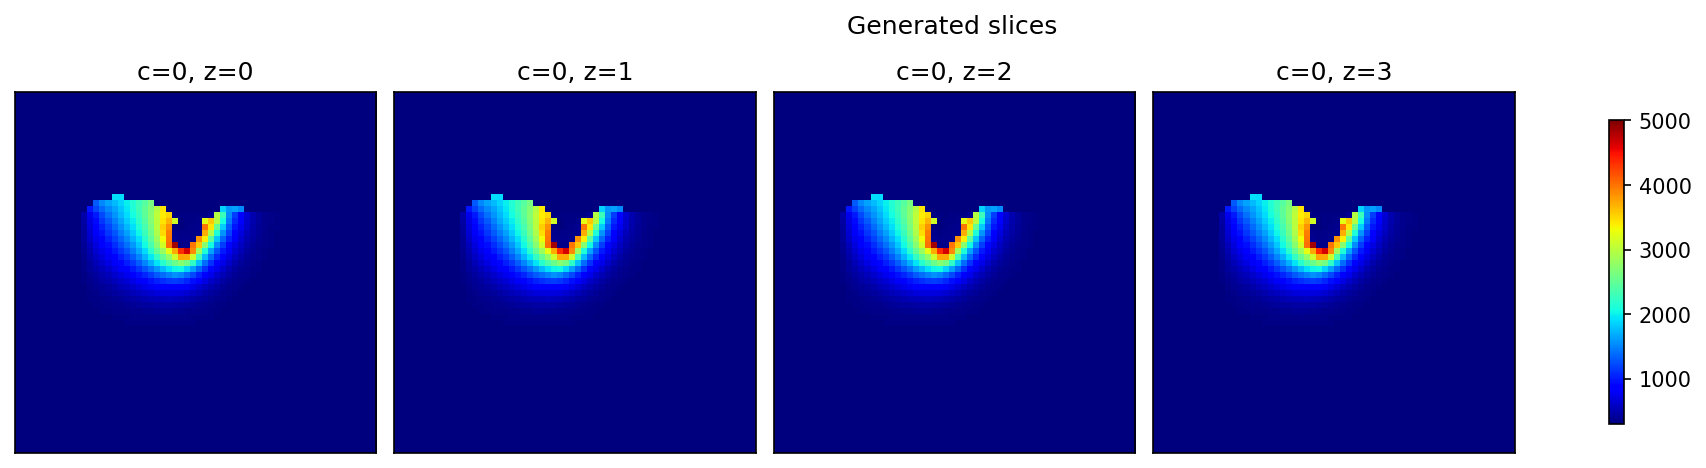

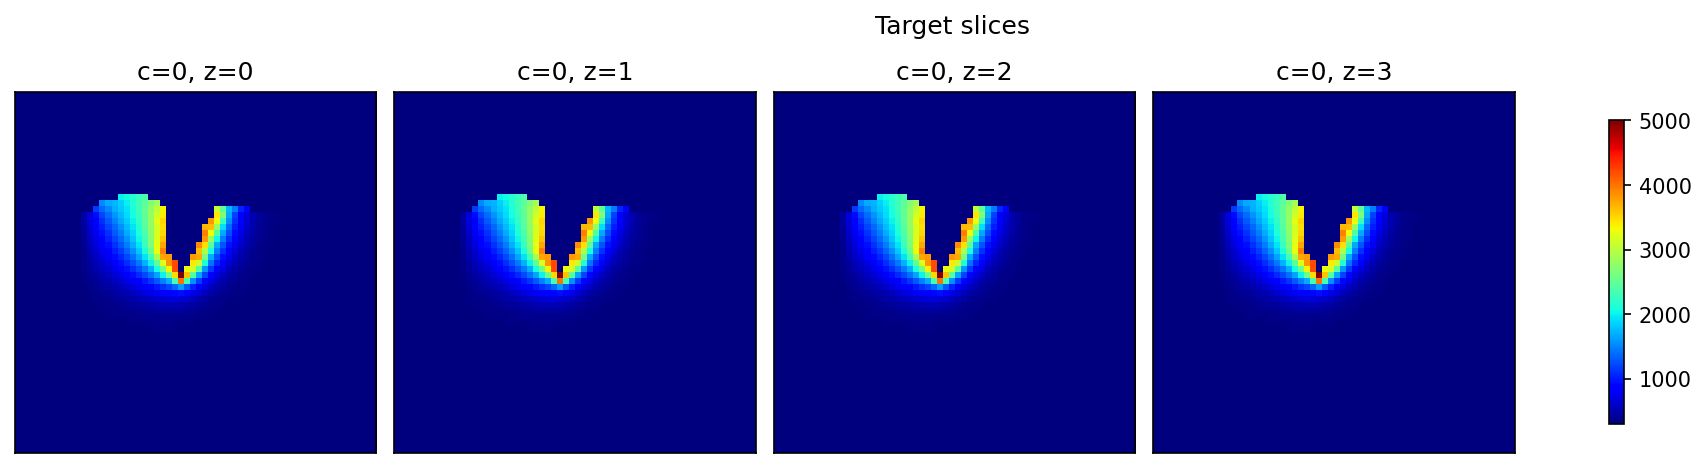

In [14]:
pred_volume_unscaled = unscale_volume(test_dataset, pred_volume, input_type="hr")
target_volume_unscaled = unscale_volume(test_dataset, target_volume, input_type="hr")
input_volume_unscaled = unscale_volume(test_dataset, input_volume, input_type="upscaled_lr")

temperature_vmin = 298
temperature_vmax = 5000

plot_volume_slices(input_volume_unscaled, f"Input slices ({sampler}, skip={skip})", vmin=temperature_vmin, vmax=temperature_vmax)
plot_volume_slices(pred_volume_unscaled, "Generated slices", vmin=temperature_vmin, vmax=temperature_vmax)
plot_volume_slices(target_volume_unscaled, "Target slices", vmin=temperature_vmin, vmax=temperature_vmax)

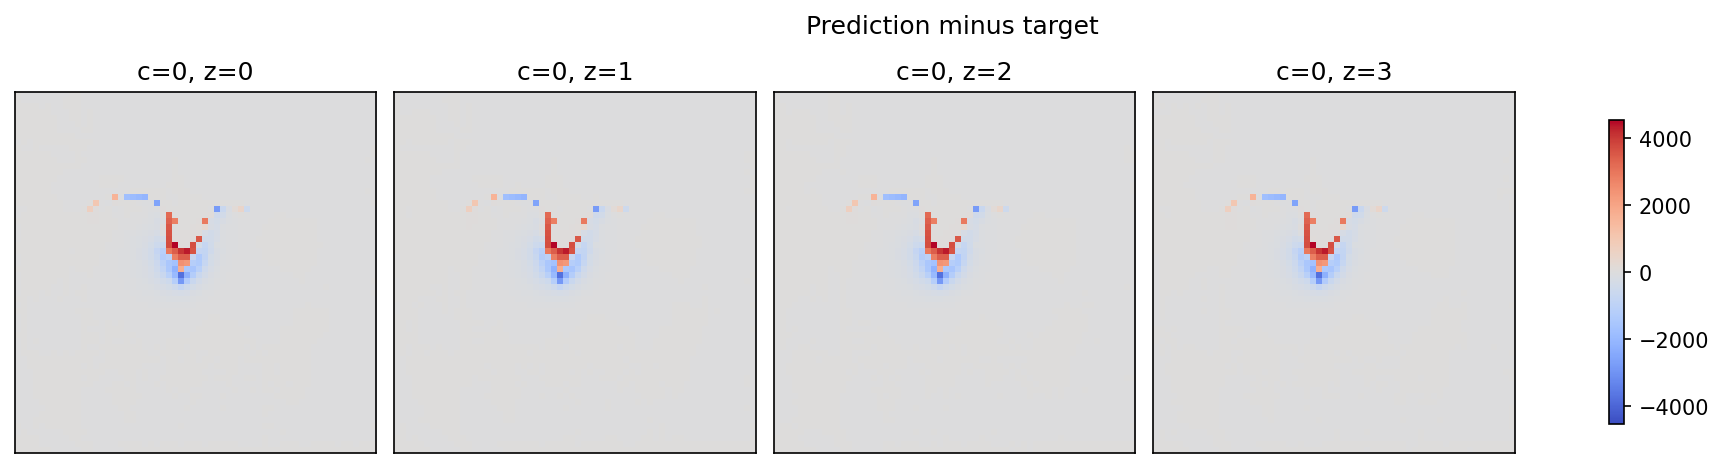

: 

In [ ]:
difference_volume = pred_volume_unscaled - target_volume_unscaled
diff_limit = float(np.max(np.abs(difference_volume)))
plot_volume_slices(difference_volume, "Prediction minus target", cmap="coolwarm", vmin=-diff_limit, vmax=diff_limit)

In [8]:
metric_channel = 0
melt_threshold = 1900.0

pred_scalar = np.asarray(pred_volume_unscaled[metric_channel])
target_scalar = np.asarray(target_volume_unscaled[metric_channel])

mae = float(np.mean(np.abs(pred_scalar - target_scalar)))

def melt_pool_profile(slice_2d, threshold=melt_threshold):
    # Mirrors diffusionsr.analysis.analysis_functions.get_profile for one slice.
    image = np.asarray(slice_2d).T
    binarized = image > threshold
    profile = []
    keyhole_profile = []
    max_idx = binarized.shape[1]
    for column_idx in range(binarized.shape[1]):
        coords = np.where(binarized[:, column_idx])[0]
        if len(coords) > 0:
            profile.append(int(np.min(coords)))
            keyhole_profile.append(int(np.max(coords)))
        else:
            profile.append(max_idx)
            keyhole_profile.append(max_idx)
    return np.asarray(profile), np.asarray(keyhole_profile)

profile_errors = []
keyhole_errors = []
for depth_idx in range(pred_scalar.shape[0]):
    pred_profile, pred_keyhole = melt_pool_profile(pred_scalar[depth_idx])
    target_profile, target_keyhole = melt_pool_profile(target_scalar[depth_idx])
    profile_errors.append(np.mean(np.abs(pred_profile - target_profile)))
    keyhole_errors.append(np.mean(np.abs(pred_keyhole - target_keyhole)))

mp_mae = float(np.mean(profile_errors))
kp_mae = float(np.mean(keyhole_errors))

pred_mask = pred_scalar >= melt_threshold
target_mask = target_scalar >= melt_threshold
vc_mae = float(np.mean(np.abs(pred_mask.astype(np.float32) - target_mask.astype(np.float32))))

metrics_summary = {
    "MAE": mae,
    "MP_MAE": mp_mae,
    "KP_MAE": kp_mae,
    "VC_MAE": vc_mae,
    "metric_channel": metric_channel,
    "melt_threshold_K": melt_threshold,
    "pred_occupied_voxels": int(pred_mask.sum()),
    "target_occupied_voxels": int(target_mask.sum()),
}

for key, value in metrics_summary.items():
    print(f"{key}: {value}")

MAE: 47.18347395704242
MP_MAE: 0.925
KP_MAE: 1.0583333333333333
VC_MAE: 0.015208333730697632
metric_channel: 0
melt_threshold_K: 1900.0
pred_occupied_voxels: 413
target_occupied_voxels: 440


In [9]:
from diffusionsr.analysis.analysis_functions import get_profile
from scipy.stats import wasserstein_distance

distribution_metric_channel = metric_channel

def extract_profile_temperatures_from_volume(volume, channel_idx=0):
    scalar_volume = np.asarray(volume[channel_idx])
    collected_values = []

    for depth_idx in range(scalar_volume.shape[0]):
        slice_2d = np.asarray(scalar_volume[depth_idx])
        image = slice_2d.T
        _, keyhole_profile = get_profile(slice_2d[None, ...], max_idx=image.shape[0])

        for column_idx, row_idx in enumerate(keyhole_profile.astype(int)):
            if row_idx < image.shape[0]:
                collected_values.append(float(image[row_idx, column_idx]))

    return np.asarray(collected_values, dtype=np.float64)

pred_distribution_values = extract_profile_temperatures_from_volume(
    pred_volume_unscaled,
    channel_idx=distribution_metric_channel,
 )
target_distribution_values = extract_profile_temperatures_from_volume(
    target_volume_unscaled,
    channel_idx=distribution_metric_channel,
 )

wasserstein_shift = float(
    wasserstein_distance(target_distribution_values, pred_distribution_values)
 )

print(f"Distribution channel: {distribution_metric_channel}")
print(f"Target sample count: {target_distribution_values.size}")
print(f"Diffusion sample count: {pred_distribution_values.size}")
print(f"Wasserstein distance (target vs diffusion): {wasserstein_shift}")

Distribution channel: 0
Target sample count: 72
Diffusion sample count: 73
Wasserstein distance (target vs diffusion): 151.243736058472


Other distance metrics
FID-> inception network based, imagenet features
Frechet distance-> same as wasserstein

In [ ]:
from diffusionsr.analysis.analysis_functions import get_profile
from scipy.stats import wasserstein_distance

analysis_sampler = "DDPM"
analysis_skip = 100  # Change this before running the cell.
analysis_metric_channel = 0
analysis_melt_threshold = 800.0
analysis_batch_size = 100  # Increase until you hit your GPU memory limit.
max_test_batches = None # Limits loader batches, not individual samples, when analysis_batch_size > 1.

if device == "cuda":
    torch.cuda.empty_cache()

def analysis_melt_pool_profile(slice_2d, threshold=800.0):
    image = np.asarray(slice_2d).T
    binarized = image > threshold
    profile = []
    keyhole_profile = []
    max_idx = binarized.shape[1]
    for column_idx in range(binarized.shape[1]):
        coords = np.where(binarized[:, column_idx])[0]
        if len(coords) > 0:
            profile.append(int(np.min(coords)))
            keyhole_profile.append(int(np.max(coords)))
        else:
            profile.append(max_idx)
            keyhole_profile.append(max_idx)
    return np.asarray(profile), np.asarray(keyhole_profile)


def extract_profile_temperatures_from_volume(volume, channel_idx=0):
    scalar_volume = np.asarray(volume[channel_idx])
    collected_values = []

    for depth_idx in range(scalar_volume.shape[0]):
        slice_2d = np.asarray(scalar_volume[depth_idx])
        image = slice_2d.T
        _, keyhole_profile = get_profile(slice_2d[None, ...], max_idx=image.shape[0])

        for column_idx, row_idx in enumerate(keyhole_profile.astype(int)):
            if row_idx < image.shape[0]:
                collected_values.append(float(image[row_idx, column_idx]))

    return np.asarray(collected_values, dtype=np.float64)


def compute_volume_metrics(pred_volume_unscaled, target_volume_unscaled, metric_channel=0, melt_threshold=800.0):
    pred_scalar = np.asarray(pred_volume_unscaled[metric_channel])
    target_scalar = np.asarray(target_volume_unscaled[metric_channel])

    mae = float(np.mean(np.abs(pred_scalar - target_scalar)))

    profile_errors = []
    keyhole_errors = []
    for depth_idx in range(pred_scalar.shape[0]):
        pred_profile, pred_keyhole = analysis_melt_pool_profile(pred_scalar[depth_idx], threshold=melt_threshold)
        target_profile, target_keyhole = analysis_melt_pool_profile(target_scalar[depth_idx], threshold=melt_threshold)
        profile_errors.append(np.mean(np.abs(pred_profile - target_profile)))
        keyhole_errors.append(np.mean(np.abs(pred_keyhole - target_keyhole)))

    mp_mae = float(np.mean(profile_errors))
    kp_mae = float(np.mean(keyhole_errors))

    pred_mask = pred_scalar >= melt_threshold
    target_mask = target_scalar >= melt_threshold
    vc_mae = float(np.mean(np.abs(pred_mask.astype(np.float32) - target_mask.astype(np.float32))))

    pred_distribution_values = extract_profile_temperatures_from_volume(
        pred_volume_unscaled,
        channel_idx=metric_channel,
    )
    target_distribution_values = extract_profile_temperatures_from_volume(
        target_volume_unscaled,
        channel_idx=metric_channel,
    )

    wasserstein_shift = float("nan")
    if pred_distribution_values.size > 0 and target_distribution_values.size > 0:
        wasserstein_shift = float(
            wasserstein_distance(target_distribution_values, pred_distribution_values)
        )

    return {
        "MAE": mae,
        "MP_MAE": mp_mae,
        "KP_MAE": kp_mae,
        "VC_MAE": vc_mae,
        "WASSERSTEIN": wasserstein_shift,
        "pred_occupied_voxels": int(pred_mask.sum()),
        "target_occupied_voxels": int(target_mask.sum()),
        "pred_profile_temp_count": int(pred_distribution_values.size),
        "target_profile_temp_count": int(target_distribution_values.size),
        "pred_min": float(pred_scalar.min()),
        "pred_max": float(pred_scalar.max()),
        "target_min": float(target_scalar.min()),
        "target_max": float(target_scalar.max()),
        "pred_distribution_values": pred_distribution_values,
        "target_distribution_values": target_distribution_values,
    }


analysis_test_dataloader = DataLoader(
    test_dataset,
    batch_size=analysis_batch_size,
    shuffle=False,
    drop_last=True,
    pin_memory=device == "cuda",
)

all_metric_rows = []
all_pred_distribution_values = []
all_target_distribution_values = []

for loader_batch_idx, (residual, hr, true_lr, upscaled_lr, info) in enumerate(analysis_test_dataloader):
    if max_test_batches is not None and loader_batch_idx >= max_test_batches:
        break

    batch_3d = diff_model.reshape_to_volume(hr.to(device).float())
    if diff_model.encoding:
        raise NotImplementedError("Whole-test-set analysis cell currently assumes encoding=False for the 3D run.")
    x_e = diff_model.reshape_to_volume(upscaled_lr.to(device).float())

    all_images = diff_model.batch_sample(
        dataset=test_dataset,
        batch=batch_3d,
        x_e=x_e,
        sampler=analysis_sampler,
        skip=analysis_skip,
    )

    pred_batch = all_images[-1].detach().cpu().numpy()
    target_batch = batch_3d.detach().cpu().numpy()
    info_batch = info.detach().cpu().numpy()

    for sample_offset in range(pred_batch.shape[0]):
        sample_idx = loader_batch_idx * analysis_batch_size + sample_offset

        pred_volume_unscaled = unscale_volume(
            test_dataset,
            pred_batch[sample_offset],
            input_type="hr",
        )
        target_volume_unscaled = unscale_volume(
            test_dataset,
            target_batch[sample_offset],
            input_type="hr",
        )

        metrics = compute_volume_metrics(
            pred_volume_unscaled=pred_volume_unscaled,
            target_volume_unscaled=target_volume_unscaled,
            metric_channel=analysis_metric_channel,
            melt_threshold=analysis_melt_threshold,
        )
        pred_distribution_values = metrics.pop("pred_distribution_values")
        target_distribution_values = metrics.pop("target_distribution_values")

        if pred_distribution_values.size > 0:
            all_pred_distribution_values.append(pred_distribution_values)
        if target_distribution_values.size > 0:
            all_target_distribution_values.append(target_distribution_values)

        metrics["sample_idx"] = sample_idx
        metrics["loader_batch_idx"] = loader_batch_idx
        metrics["power"] = float(info_batch[sample_offset][0])
        metrics["velocity"] = float(info_batch[sample_offset][1])
        metrics["time"] = float(info_batch[sample_offset][2])
        all_metric_rows.append(metrics)

if len(all_metric_rows) == 0:
    raise ValueError("No test samples were processed. Check max_test_batches and analysis_batch_size.")

mae_values = np.asarray([row["MAE"] for row in all_metric_rows], dtype=np.float64)
wasserstein_values = np.asarray(
    [row["WASSERSTEIN"] for row in all_metric_rows if np.isfinite(row["WASSERSTEIN"])],
    dtype=np.float64,
 )
sorted_mae_values = np.sort(mae_values)
top_k = min(10, len(all_metric_rows))
top_mae_rows = sorted(all_metric_rows, key=lambda row: row["MAE"], reverse=True)[:top_k]
top_1pct_count = max(1, int(np.ceil(0.01 * len(sorted_mae_values))))
trimmed_mae_values = sorted_mae_values[:-top_1pct_count] if len(sorted_mae_values) > top_1pct_count else sorted_mae_values
median_mae = float(np.median(mae_values))
suspicious_factor = 10.0
suspicious_count = int(np.sum(mae_values > suspicious_factor * median_mae)) if median_mae > 0 else 0

global_pred_distribution_values = np.concatenate(all_pred_distribution_values) if all_pred_distribution_values else np.asarray([], dtype=np.float64)
global_target_distribution_values = np.concatenate(all_target_distribution_values) if all_target_distribution_values else np.asarray([], dtype=np.float64)
global_wasserstein = float("nan")
if global_pred_distribution_values.size > 0 and global_target_distribution_values.size > 0:
    global_wasserstein = float(
        wasserstein_distance(
            global_target_distribution_values,
            global_pred_distribution_values,
        )
    )

avg_metrics = {
    "num_loader_batches": loader_batch_idx + 1,
    "num_samples": len(all_metric_rows),
    "analysis_sampler": analysis_sampler,
    "analysis_skip": analysis_skip,
    "analysis_metric_channel": analysis_metric_channel,
    "analysis_melt_threshold": analysis_melt_threshold,
    "analysis_batch_size": analysis_batch_size,
}

for metric_name in [
    "MAE",
    "MP_MAE",
    "KP_MAE",
    "VC_MAE",
    "pred_occupied_voxels",
    "target_occupied_voxels",
    "pred_profile_temp_count",
    "target_profile_temp_count",
]:
    avg_metrics[metric_name] = float(np.mean([row[metric_name] for row in all_metric_rows]))

if wasserstein_values.size > 0:
    avg_metrics["WASSERSTEIN_mean"] = float(np.mean(wasserstein_values))
    avg_metrics["WASSERSTEIN_median"] = float(np.median(wasserstein_values))
    avg_metrics["WASSERSTEIN_p95"] = float(np.percentile(wasserstein_values, 95))
    avg_metrics["WASSERSTEIN_max"] = float(np.max(wasserstein_values))
else:
    avg_metrics["WASSERSTEIN_mean"] = float("nan")
    avg_metrics["WASSERSTEIN_median"] = float("nan")
    avg_metrics["WASSERSTEIN_p95"] = float("nan")
    avg_metrics["WASSERSTEIN_max"] = float("nan")

avg_metrics["WASSERSTEIN_global_profile_temperature"] = global_wasserstein
avg_metrics["global_pred_profile_temp_count"] = int(global_pred_distribution_values.size)
avg_metrics["global_target_profile_temp_count"] = int(global_target_distribution_values.size)
avg_metrics["MAE_median"] = median_mae
avg_metrics["MAE_p95"] = float(np.percentile(mae_values, 95))
avg_metrics["MAE_p99"] = float(np.percentile(mae_values, 99))
avg_metrics["MAE_max"] = float(np.max(mae_values))
avg_metrics["MAE_mean_excluding_top_1pct"] = float(np.mean(trimmed_mae_values))
avg_metrics["num_samples_above_10x_median_MAE"] = suspicious_count

for key, value in avg_metrics.items():
    print(f"{key}: {value}")

print("\nTop samples by MAE:")
for row in top_mae_rows:
    print({
        "sample_idx": row["sample_idx"],
        "loader_batch_idx": row["loader_batch_idx"],
        "MAE": row["MAE"],
        "WASSERSTEIN": row["WASSERSTEIN"],
        "pred_min": row["pred_min"],
        "pred_max": row["pred_max"],
        "target_min": row["target_min"],
        "target_max": row["target_max"],
        "power": row["power"],
        "velocity": row["velocity"],
        "time": row["time"],
    })

all_metric_rows[:3]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 